# Observations
- 20260312: all conditions are based on fast learning (1e-3) so that we can observe more convergence across runs. 
- 20260315: increased EWC strength from 1.0 to 10000.0, making EWC penalty comparable with task loss. Fixed some bugs in EWC implementation. 
- 20260317: shrank down hidden dimension to 2, hopefully it will make EWC less advantageous. Originally we had dim = 4, and with this setting we got EWC > NFZ for both L1 and L2. This seems rather weird. Therefore, I doubted whether it could be due to over-powered hidden representation, thus making it best not to move any L1 parameters but to start with new dimensions, and EWC was exactly doing this, making it better than NFZ. In this version, we make hidden dimension = 2. With more limited hidden dimensions, we anticipate to see some difference. 
- 20260319: Because we still saw quite obvious advantage of EWC for both Para and Vert, I doubted whether it is due to the model in general being too powerful. Therefore, I ran a simplistic FC Recon model and this is the result. 

Comparison is between NFZ and EWC, PARA and VERT. 

L1: s-c

L2: sh-ch / tsh-sh

In [1]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from itertools import product
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
def L1_condition_mapper(condition):
    if "_RCRC" in condition or "_RCCL" in condition:
        return "Recon"
    elif "_CLRC" in condition or "_CLCL" in condition:
        return "Class"

def L2_condition_mapper(condition):
    if "_RCRC" in condition or "_CLRC" in condition:
        return "Recon"
    elif "_RCCL" in condition or "_CLCL" in condition:
        return "Class"
    
def freezing_condition_mapper(condition):
    if "_FZ" in condition:
        return "Freeze"
    elif "_NFZ" in condition:
        return "NoFreeze"
    elif "_EWC" in condition:
        return "EWC"
    elif "_NPT" in condition:
        return "NoPreTrain"

def learning_rate_condition_mapper(condition):
    if "_1e5" in condition:
        return "slow"
    elif "_1e4" in condition:
        return "fast"
    elif "_1e3" in condition:
        return "superfast"
    
def L2_inventory_condition_mapper(condition):
    if "_PARA" in condition:
        return "Para"
    elif "_VERT" in condition:
        return "Vert"
    
def model_hid_size_condition_mapper(condition):
    if "_HID" in condition:
        # then get the number after HID
        hid_size = condition.split("_HID")[1].split("_")[0]
        return hid_size
    else: 
        return "4"

## EWC vs NPZ (enlarged weight)

In [ ]:
BASE_PATH = "./observations/"

PREFIX = "0312"
L1_CONDITIONS = ["RC"]
L2_CONDITIONS = ["RC", "CL"]
FREEZING_CONDITIONS = ["NFZ", "EWC"]
LEARNING_RATE_CONDITIONS = ["1e3"]  # , 
L2_INVENTORY_CONDITIONS = ["PARA", "VERT"]
HID_SIZE = [""] # 
EVAL_METHODS = ["silhouette"]

condition_pool = [
    f"{PREFIX}_{l1}{l2}_{inv}_{freezing}_{lr}{hid}"
    for l1, l2, freezing, lr, inv, hid in product(
        L1_CONDITIONS,
        L2_CONDITIONS,
        FREEZING_CONDITIONS,
        LEARNING_RATE_CONDITIONS,
        L2_INVENTORY_CONDITIONS,
        HID_SIZE,
    )
]

EPOCH_START = 10
EPOCH_END = 300
RUNS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

TRAIN_MAP = {
    "sh_ch": "L2", "s_c": "L1", "tsh_sh": "L2"
}

integrated_df = pd.DataFrame()
for condition in condition_pool: 
    condition_path = BASE_PATH + condition + "/"
    for epoch in range(EPOCH_START, EPOCH_END + 1, 10): 
        for run in RUNS:    # currently only one run, but we want to average over multiple runs if existing
            for eval_method in EVAL_METHODS:
                file_path = condition_path + f"{eval_method}_E{epoch}_R{run}.csv"
                df = pd.read_csv(file_path)
                
                scores = df["sil_score"].tolist()
                scores_cos = df["sil_score_cos"].tolist()
                train_langs = [TRAIN_MAP[t] if t in TRAIN_MAP else "N/A" for t in df["sil_type"].tolist()]

                result_df = pd.DataFrame({
                    "L1_condition": [L1_condition_mapper(condition)] * len(scores),
                    "L2_condition": [L2_condition_mapper(condition)] * len(scores),
                    "freezing_condition": [freezing_condition_mapper(condition)] * len(scores),
                    "learning_rate_condition": [learning_rate_condition_mapper(condition)] * len(scores),
                    "L2_inventory_condition": [L2_inventory_condition_mapper(condition)] * len(scores),
                    "hid_size_condition": [model_hid_size_condition_mapper(condition)] * len(scores),
                    "contrast_pair": df["sil_type"].tolist(),
                    "train_lang": train_langs,
                    "eval_method": [eval_method] * len(scores),
                    "sil_score": scores, 
                    "sil_score_cos": scores_cos,
                    "run": [run] * len(scores),
                    "epoch": [epoch] * len(scores)})
                integrated_df = pd.concat([integrated_df, result_df], ignore_index=True)
    

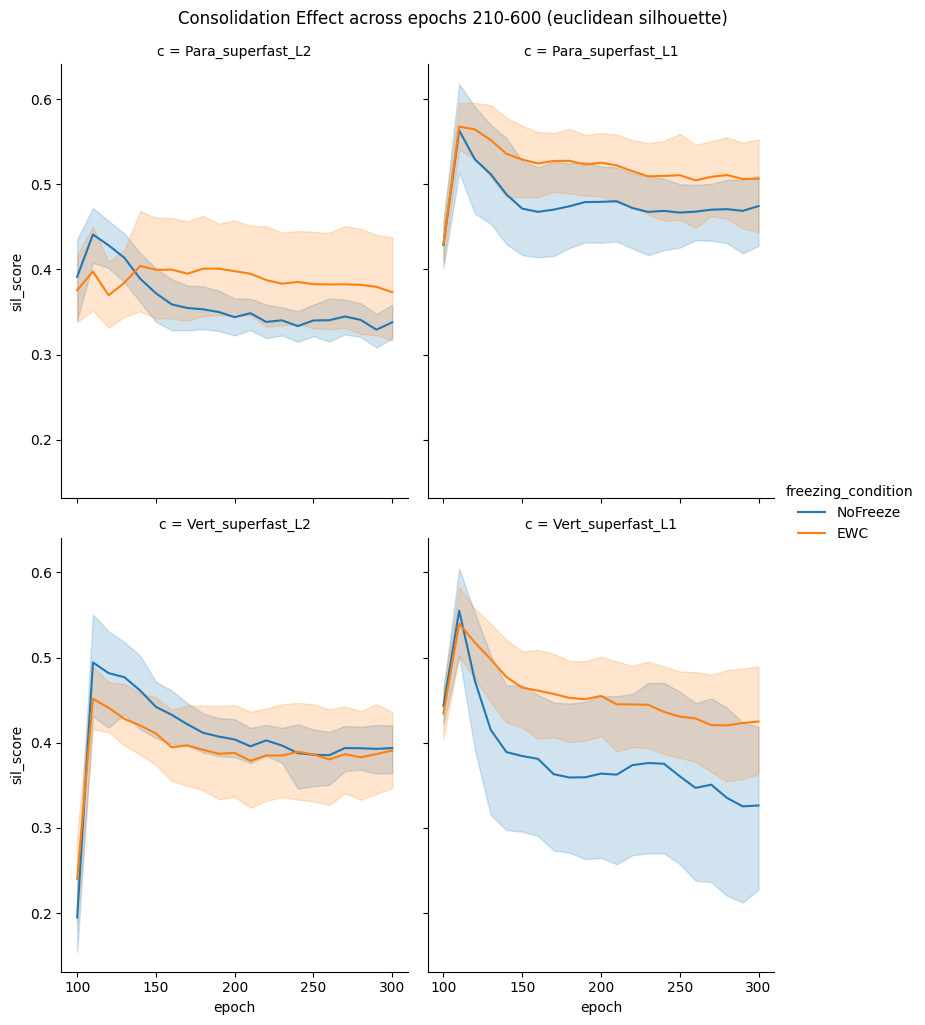

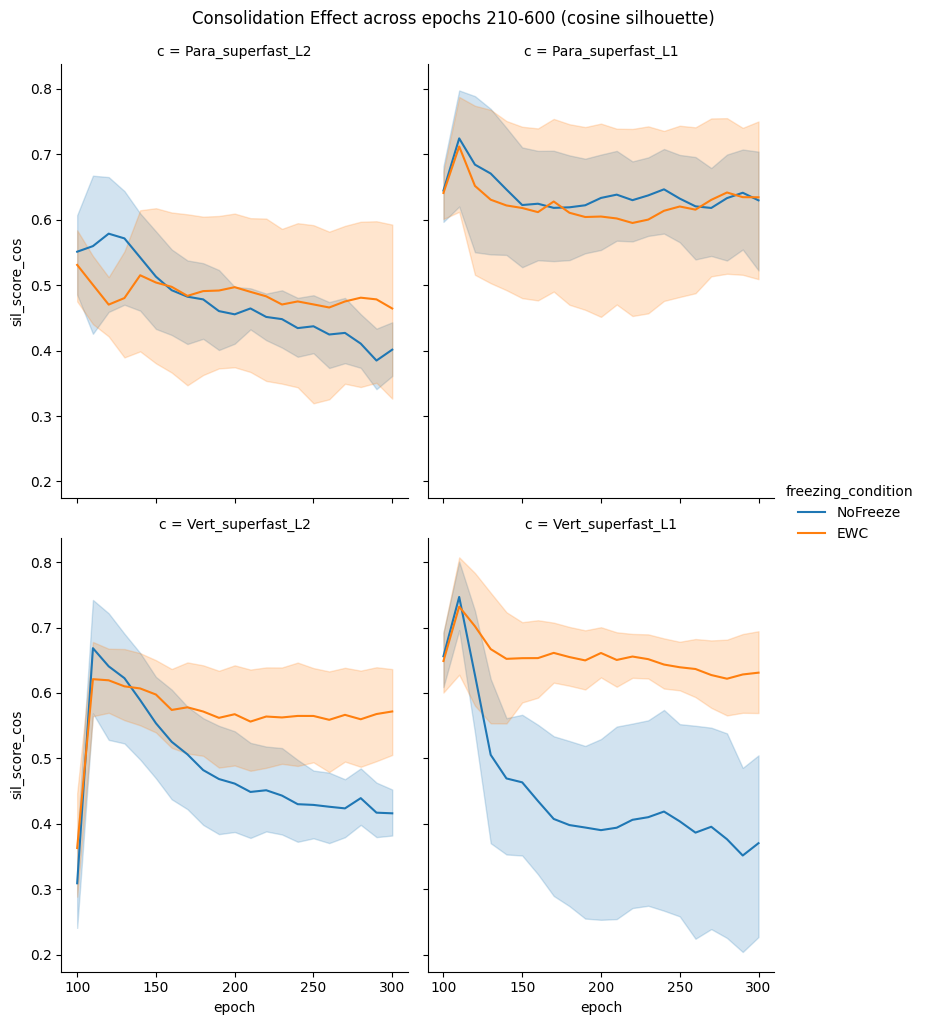

In [31]:
df = integrated_df.copy()
df["combined_inv_lr"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"]
df = df[df["train_lang"].isin(["L1", "L2"])]
# df = df[df["learning_rate_condition"] == "fast"]
df = df[df["epoch"].isin(range(100, 301, 10))]
df["c"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"] + "_" + df["train_lang"]

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score",
    hue="freezing_condition",
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (euclidean silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(100, 301, 50))

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score_cos",
    hue="freezing_condition",
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (cosine silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(100, 301, 50))

## EWC vs NPZ (hid = 2)

In [32]:
BASE_PATH = "./observations/"

PREFIX = "0315"
L1_CONDITIONS = ["RC"]
L2_CONDITIONS = ["RC"]
FREEZING_CONDITIONS = ["NFZ", "EWC"]
LEARNING_RATE_CONDITIONS = ["1e3"]  # , 
L2_INVENTORY_CONDITIONS = ["PARA", "VERT"]
HID_SIZE = ["_HID2"] # 
EVAL_METHODS = ["silhouette"]

condition_pool = [
    f"{PREFIX}_{l1}{l2}_{inv}_{freezing}_{lr}{hid}"
    for l1, l2, freezing, lr, inv, hid in product(
        L1_CONDITIONS,
        L2_CONDITIONS,
        FREEZING_CONDITIONS,
        LEARNING_RATE_CONDITIONS,
        L2_INVENTORY_CONDITIONS,
        HID_SIZE,
    )
]

EPOCH_START = 10
EPOCH_END = 600
RUNS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

TRAIN_MAP = {
    "sh_ch": "L2", "s_c": "L1", "tsh_sh": "L2"
}

integrated_df = pd.DataFrame()
for condition in condition_pool: 
    condition_path = BASE_PATH + condition + "/"
    for epoch in range(EPOCH_START, EPOCH_END + 1, 10): 
        for run in RUNS:    # currently only one run, but we want to average over multiple runs if existing
            for eval_method in EVAL_METHODS:
                file_path = condition_path + f"{eval_method}_E{epoch}_R{run}.csv"
                df = pd.read_csv(file_path)
                
                scores = df["sil_score"].tolist()
                scores_cos = df["sil_score_cos"].tolist()
                train_langs = [TRAIN_MAP[t] if t in TRAIN_MAP else "N/A" for t in df["sil_type"].tolist()]

                result_df = pd.DataFrame({
                    "L1_condition": [L1_condition_mapper(condition)] * len(scores),
                    "L2_condition": [L2_condition_mapper(condition)] * len(scores),
                    "freezing_condition": [freezing_condition_mapper(condition)] * len(scores),
                    "learning_rate_condition": [learning_rate_condition_mapper(condition)] * len(scores),
                    "L2_inventory_condition": [L2_inventory_condition_mapper(condition)] * len(scores),
                    "hid_size_condition": [model_hid_size_condition_mapper(condition)] * len(scores),
                    "contrast_pair": df["sil_type"].tolist(),
                    "train_lang": train_langs,
                    "eval_method": [eval_method] * len(scores),
                    "sil_score": scores, 
                    "sil_score_cos": scores_cos,
                    "run": [run] * len(scores),
                    "epoch": [epoch] * len(scores)})
                integrated_df = pd.concat([integrated_df, result_df], ignore_index=True)
    

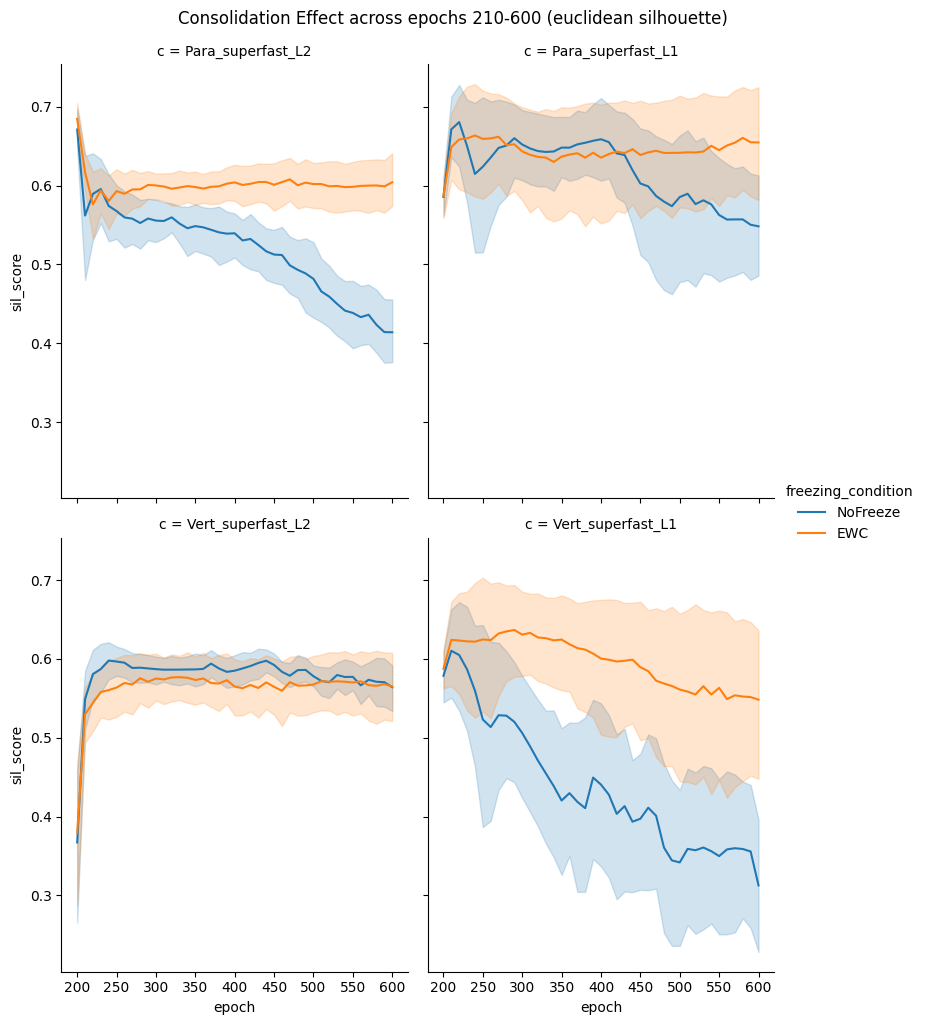

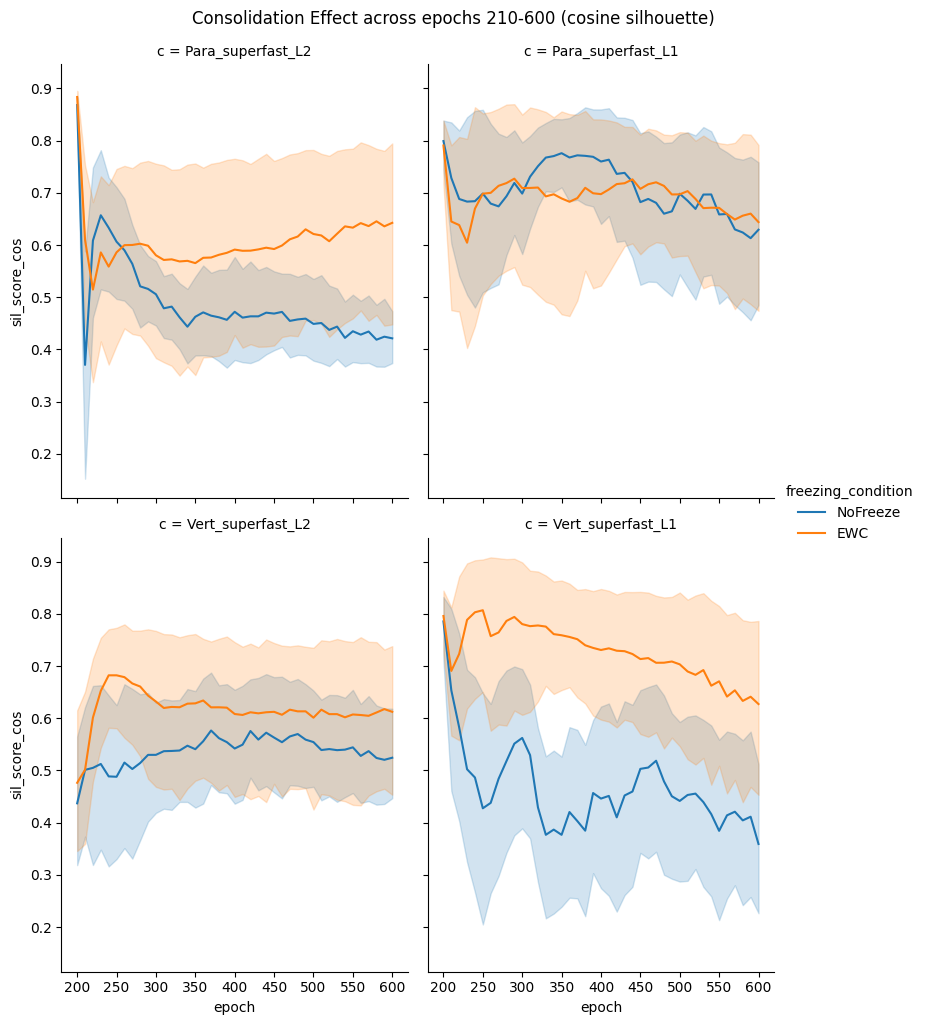

In [33]:
df = integrated_df.copy()
df["combined_inv_lr"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"]
df = df[df["train_lang"].isin(["L1", "L2"])]
# df = df[df["learning_rate_condition"] == "fast"]
df = df[df["epoch"].isin(range(200, 601, 10))]
df["c"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"] + "_" + df["train_lang"]

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score",
    hue="freezing_condition",
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (euclidean silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(200, 601, 50))

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score_cos",
    hue="freezing_condition",
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (cosine silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(200, 601, 50))

## NFZ vs EWC (FC, hid=2)

In [3]:
BASE_PATH = "./observations/"

PREFIX = "0317"
L1_CONDITIONS = ["RC"]
L2_CONDITIONS = ["RC", "CL"]
FREEZING_CONDITIONS = ["NFZ", "EWC"]
LEARNING_RATE_CONDITIONS = ["1e3"]  # , 
L2_INVENTORY_CONDITIONS = ["PARA", "VERT"]
HID_SIZE = ["_HID2"] # 
EVAL_METHODS = ["silhouette"]

condition_pool = [
    f"{PREFIX}_{l1}{l2}_{inv}_{freezing}_{lr}{hid}"
    for l1, l2, freezing, lr, inv, hid in product(
        L1_CONDITIONS,
        L2_CONDITIONS,
        FREEZING_CONDITIONS,
        LEARNING_RATE_CONDITIONS,
        L2_INVENTORY_CONDITIONS,
        HID_SIZE,
    )
]

EPOCH_START = 10
EPOCH_END = 600
RUNS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

TRAIN_MAP = {
    "sh_ch": "L2", "s_c": "L1", "tsh_sh": "L2"
}

integrated_df = pd.DataFrame()
for condition in condition_pool: 
    condition_path = BASE_PATH + condition + "/"
    for epoch in range(EPOCH_START, EPOCH_END + 1, 10): 
        for run in RUNS:    # currently only one run, but we want to average over multiple runs if existing
            for eval_method in EVAL_METHODS:
                file_path = condition_path + f"{eval_method}_E{epoch}_R{run}.csv"
                df = pd.read_csv(file_path)
                
                scores = df["sil_score"].tolist()
                scores_cos = df["sil_score_cos"].tolist()
                train_langs = [TRAIN_MAP[t] if t in TRAIN_MAP else "N/A" for t in df["sil_type"].tolist()]

                result_df = pd.DataFrame({
                    "L1_condition": [L1_condition_mapper(condition)] * len(scores),
                    "L2_condition": [L2_condition_mapper(condition)] * len(scores),
                    "freezing_condition": [freezing_condition_mapper(condition)] * len(scores),
                    "learning_rate_condition": [learning_rate_condition_mapper(condition)] * len(scores),
                    "L2_inventory_condition": [L2_inventory_condition_mapper(condition)] * len(scores),
                    "hid_size_condition": [model_hid_size_condition_mapper(condition)] * len(scores),
                    "contrast_pair": df["sil_type"].tolist(),
                    "train_lang": train_langs,
                    "eval_method": [eval_method] * len(scores),
                    "sil_score": scores, 
                    "sil_score_cos": scores_cos,
                    "run": [run] * len(scores),
                    "epoch": [epoch] * len(scores)})
                integrated_df = pd.concat([integrated_df, result_df], ignore_index=True)
    

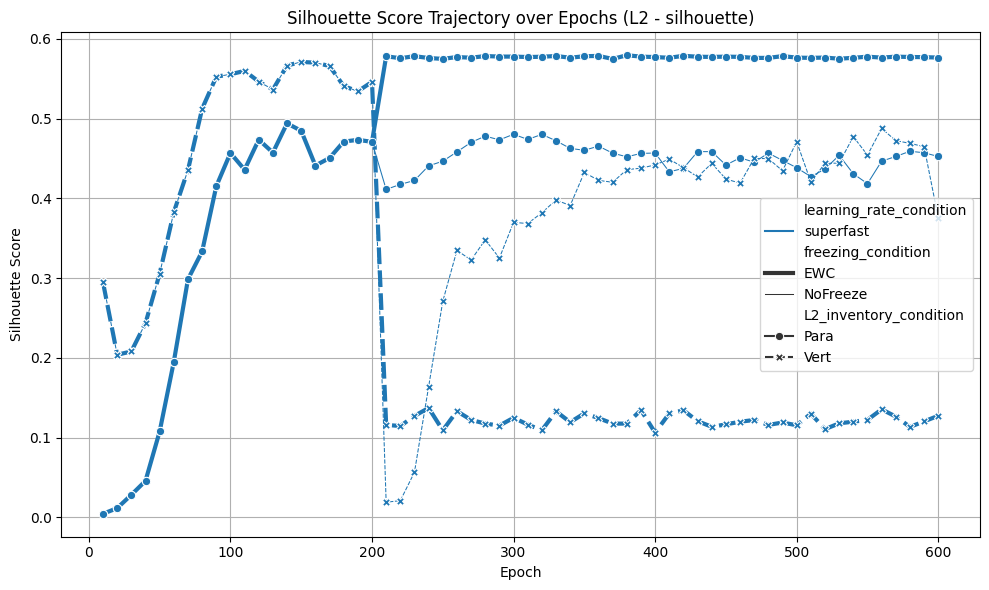

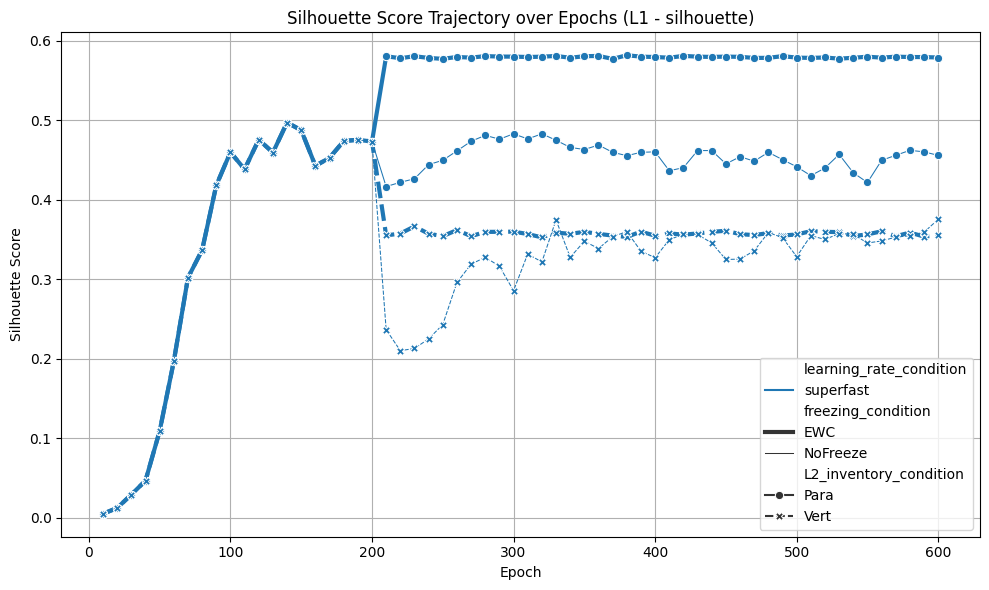

In [35]:
all_plot_df = integrated_df.copy()
train_lang_list = ["L2", "L1"]
eval_method_list = ["silhouette"]
for train_lang in train_lang_list:
    for eval_method in eval_method_list:
        subset_df = all_plot_df[(all_plot_df["train_lang"] == train_lang) & (all_plot_df["eval_method"] == eval_method)]
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=subset_df, x="epoch", y="sil_score", 
                     hue="learning_rate_condition", style="L2_inventory_condition", 
                     size="freezing_condition", size_order=["EWC", "NoFreeze"], markers=True, errorbar=None)
        plt.title(f"Silhouette Score Trajectory over Epochs ({train_lang} - {eval_method})")
        plt.xlabel("Epoch")
        plt.ylabel("Silhouette Score")
        # plt.ylim(0.25, 0.7)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

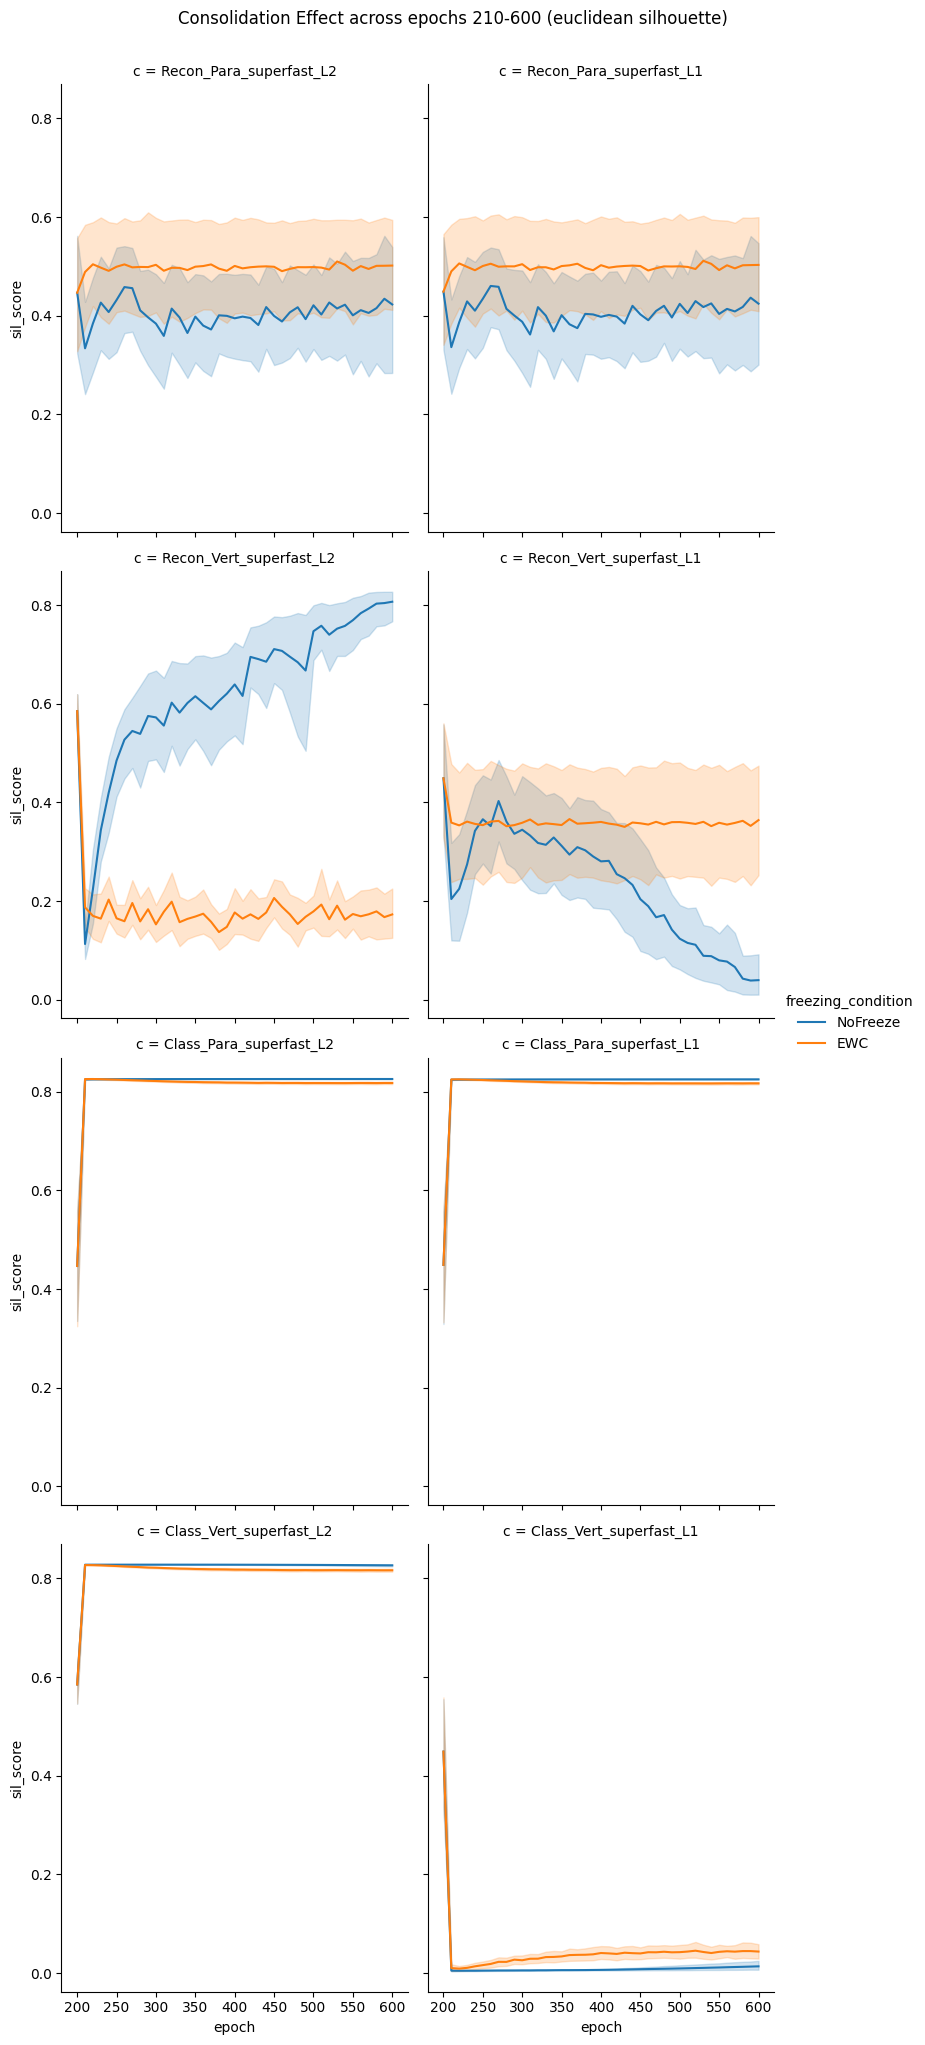

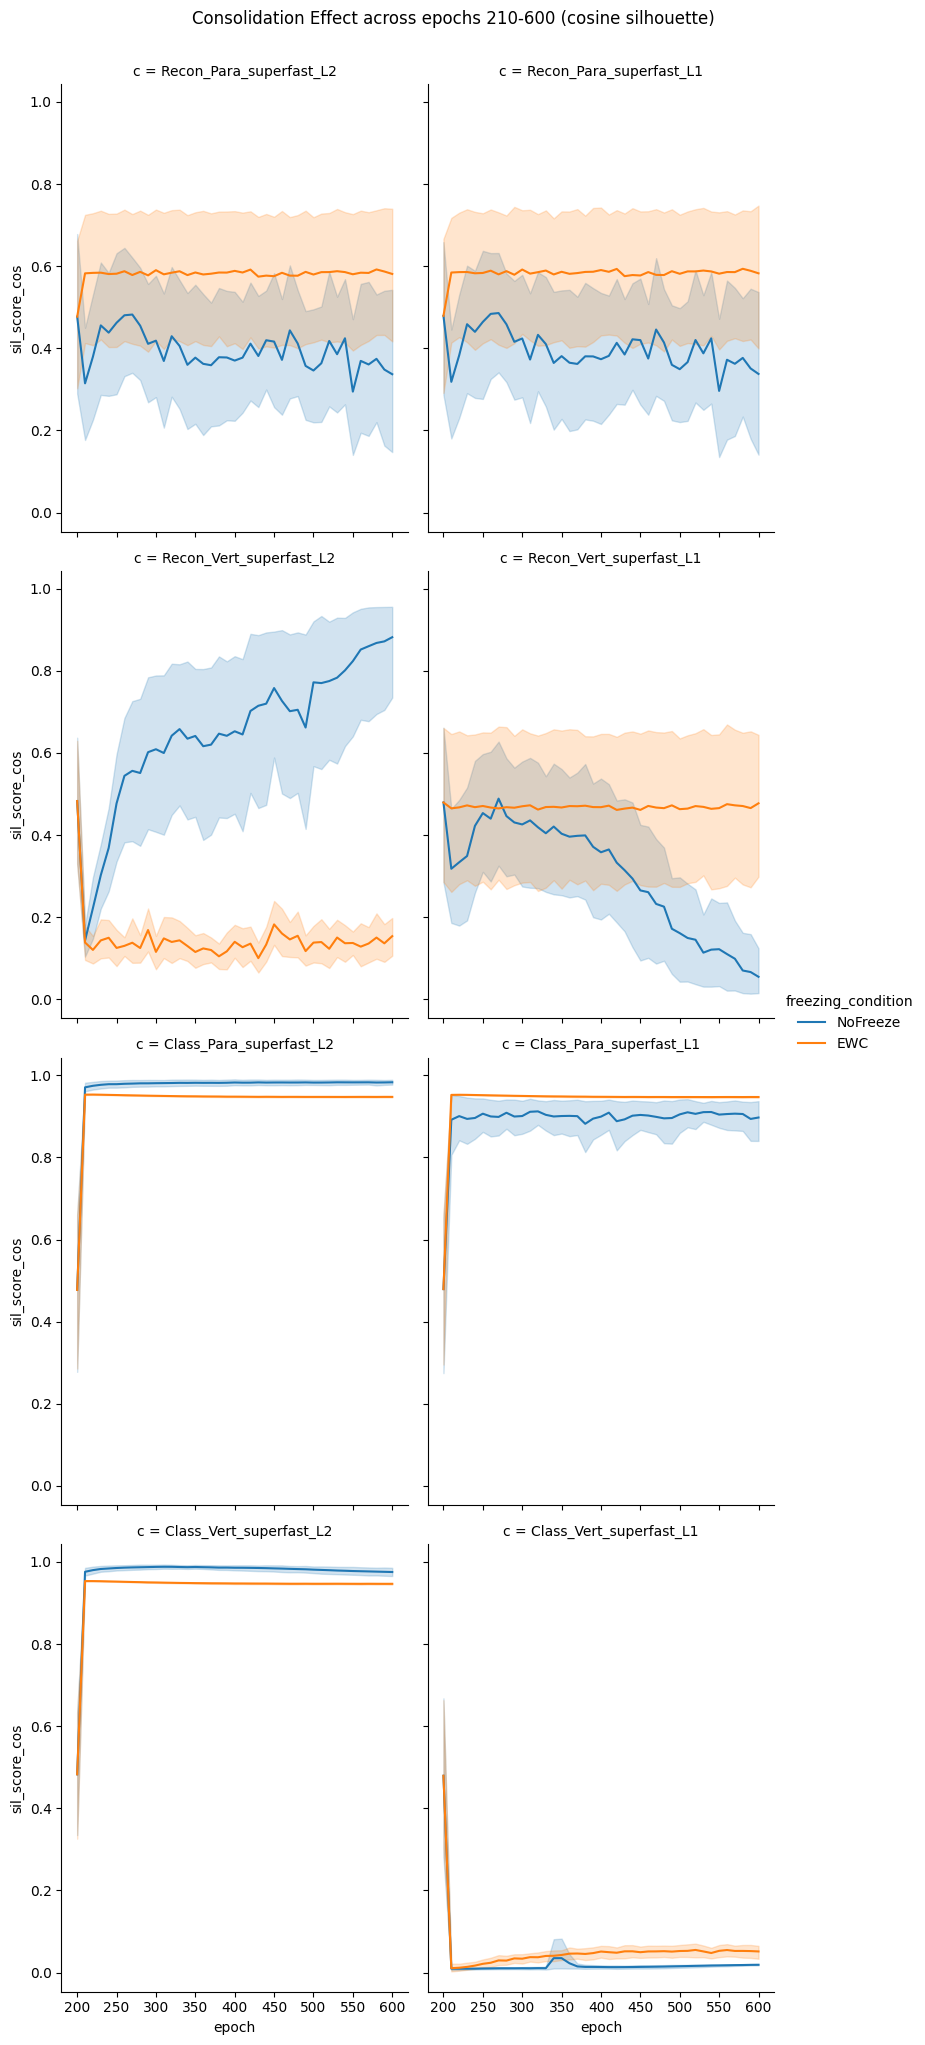

In [5]:
df = integrated_df.copy()
df["combined_inv_lr"] = df["L2_inventory_condition"] + "_" + df["learning_rate_condition"]
df = df[df["train_lang"].isin(["L1", "L2"])]
# df = df[df["learning_rate_condition"] == "fast"]
df = df[df["epoch"].isin(range(200, 601, 10))]
df["c"] = df["L2_condition"] + "_" + df["L2_inventory_condition"] + "_" + df["learning_rate_condition"] + "_" + df["train_lang"]

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score",
    hue="freezing_condition",
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (euclidean silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(200, 601, 50))

g = sns.relplot(
    data=df,
    x="epoch",
    y="sil_score_cos",
    hue="freezing_condition",
    col="c",
    col_wrap=2,
    kind="line",
    errorbar=("ci", 95),
    aspect=0.8
)

g.fig.suptitle("Consolidation Effect across epochs 210-600 (cosine silhouette)", y=1.02)
for ax in g.axes.flatten():
    ax.set_xticks(range(200, 601, 50))

# Conclusions
## Enlarging EWC
Enlarging EWC strength did make the comparison between EWC and NFZ more realistic. Specifically, now, L1 preservation is much better when using EWC than when not. This means that, in fact, there is L1 learning and it is not always the same as L2 (unlike what we concluded last time from No-Pretrain conditions). However, we also see benefit of L2 learning from consolidation. This is not so ideal, because we would expect adults to learn worse for DL because of consolidation. Although this is not guaranteed to happen, I would want to see what could have caused consolidated model to learn L2 even better. 

One guess would be the overly large hidden representation space: because learning all of them only requires at most 2 dimensions, if we shrink it to like 1, will that make a difference? 

## Shrinking hidden dimension
This result indicates that EWC would be helpful for L1 retainment, but will not do much harm to L2 learning (if L2 is orthogonal to L1), and will even help L2 learning for Para condition. This could still be due to overly large hidden dimension, I may proceed to try hiddim = 1, but this is a bit risky, since there might be bugs somewhere, especially for squeezing. 

But given such results, it seems not so likely that changing dim to 1 will completely change the picture. Maybe consolidation is not bad, or we need to think of another implementation for adult. 

However, it could also be due to the model being too expressive. Therefore, I tried FC model with hiddim = 2. 

## FC Model
Finally! With FC model, hiddim = 2, we finally see EWC to harm L2 learning (Vert). This could be interpreted as the harm of consolidation to learning. 